# Detecção de eixos de caminhões utilizando YOLOv8

Esse notebook contém uma análise e detalhamento dos estágios de pré-processamento e tratamento do conjunto de dados, assim como a descrição dos procedimentos feitos com o YOLOv8 para a detecção de pneus e eixos nas imagens.

## 1.0 Introdução ao projeto

### 1.1 Problema tratado

O problema que será tratado nesse trabalho é uma redução de escopo de um projeto maior iniciado pela Secretaria da Fazendo do Estado da Paraíba (SEFAZ-PB). No objetivo geral, busca-se reduzir a imprecisão na geração de alertas para auditores sobre veículos com possíveis incongruências entre a carga transportada e a declarada em notas fiscais.

### 1.2 Solução proposta

A solução proposta envolve o uso de algoritmos de inteligência artificial para a detecção dos eixos de caminhões em imagens capturadas por câmeras de vigilância. O eixo é um fator determinante no cálculo da carga máxima suportada pelo caminhão e a análise do algoritmo poderia ser comparada às informações obtidas na nota fiscal para revelar possíveis infrações. Nesse contexto, o presente trabalho se concentra nas etapas iniciais do escopo geral supracitado, ou seja, a detecção de eixos.

## 2.0 Pipeline de desenvolvimento

A criação de uma solução como a proposta exige a subdivisão do objetivo final em tarefas menores que permitam o desenvolvimento adequado do algoritmo. A sequência de passos tomados para esse trabalho está descrita abaixo.

### 2.1 Análise e pré-processamento dos dados


Os dados utilizados neste trabalho consistem em imagens recentes de câmeras de vigilância públicas, contendo caminhões e outros veículos. Essas imagens foram obtidas diretamente do banco de dados disponibilizado pela SEFAZ-PB, totalizando cerca de mil instâncias. Como esperado, parte delas mostrou-se inadequada para o treinamento devido aos seguintes fatores:

*   A imagem não continha nenhum caminhão;

*   A imagem continha um caminhão, mas o ângulo da foto escondia todos os pneus, impossibilitando qualquer rotulagem futura;

*   A qualidade da imagem impedia a distinção de qualquer característica relevante do caminhão. Isso ocorria, sobretudo, em imagens noturnas afetadas pela ausência de luminosidade no instante da captura.

Exemplos de imagens nessas configurações podem ser encontrados abaixo:

#### 1. Imagens noturnas com características indistinguíveis para treinamento

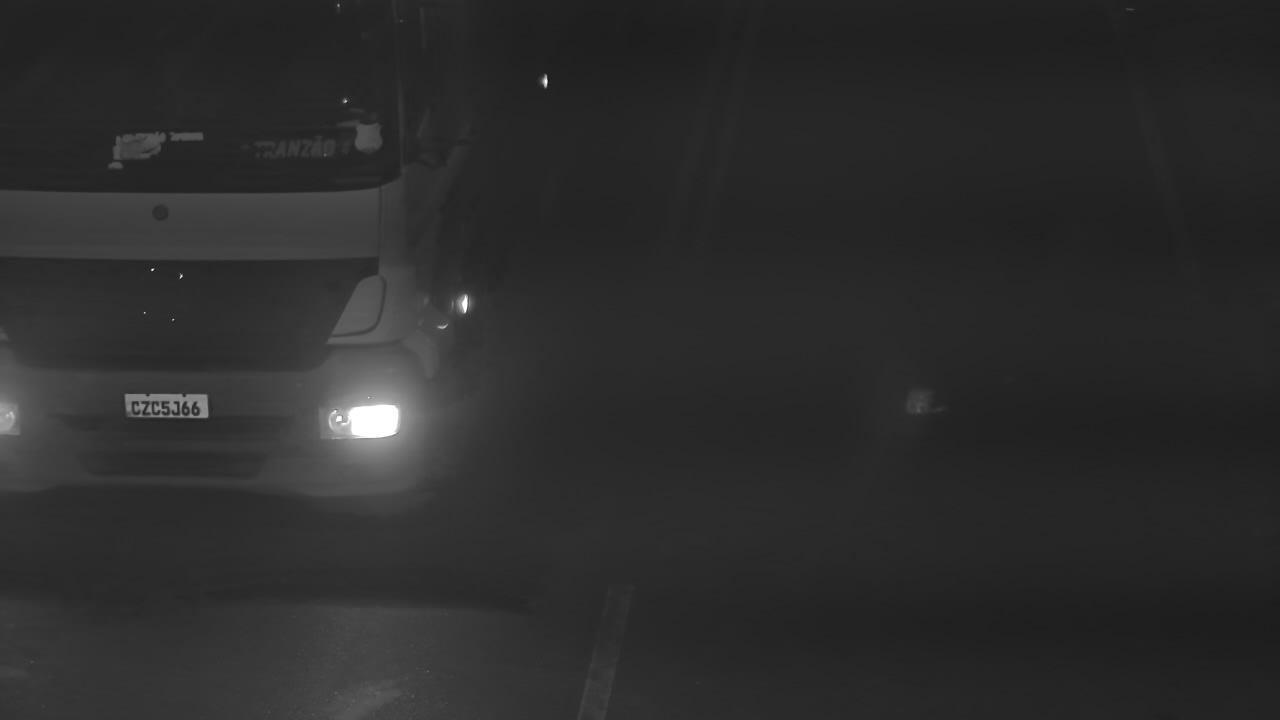

#### 2. Imagens de outros veículos e sem caminhões


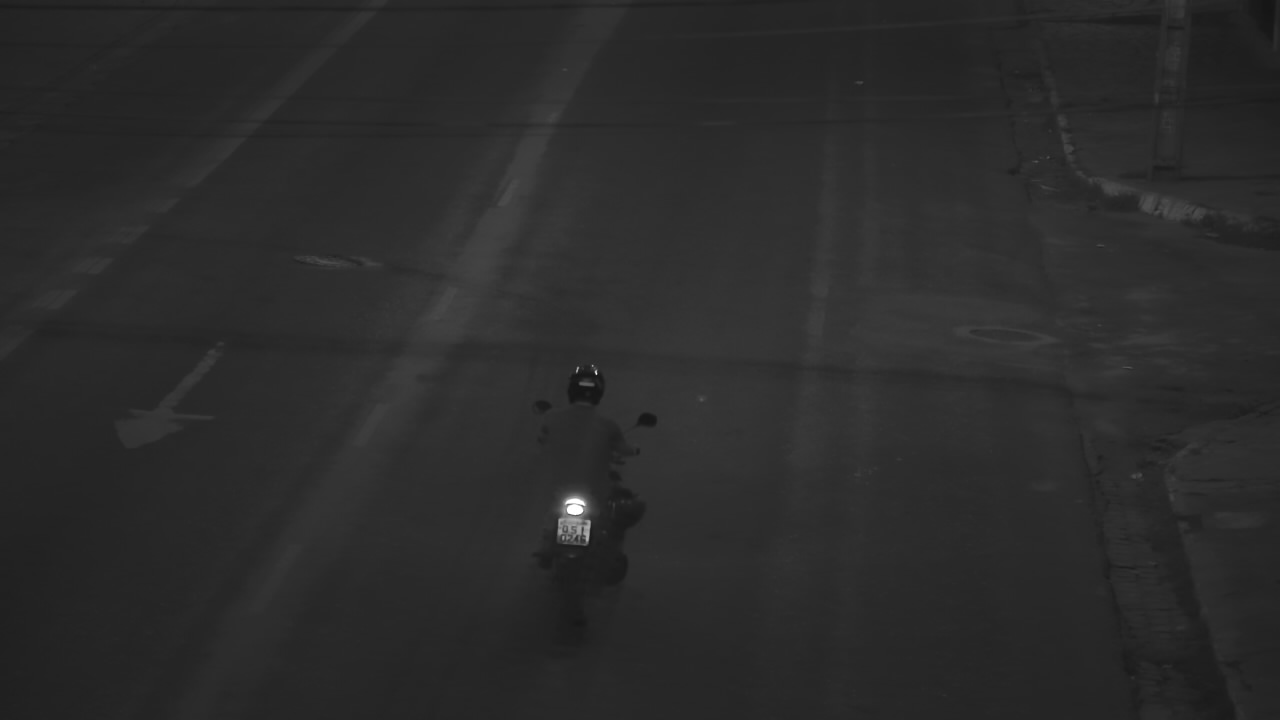

#### 3. Imagens de caminhões sem visibilidade de pneus

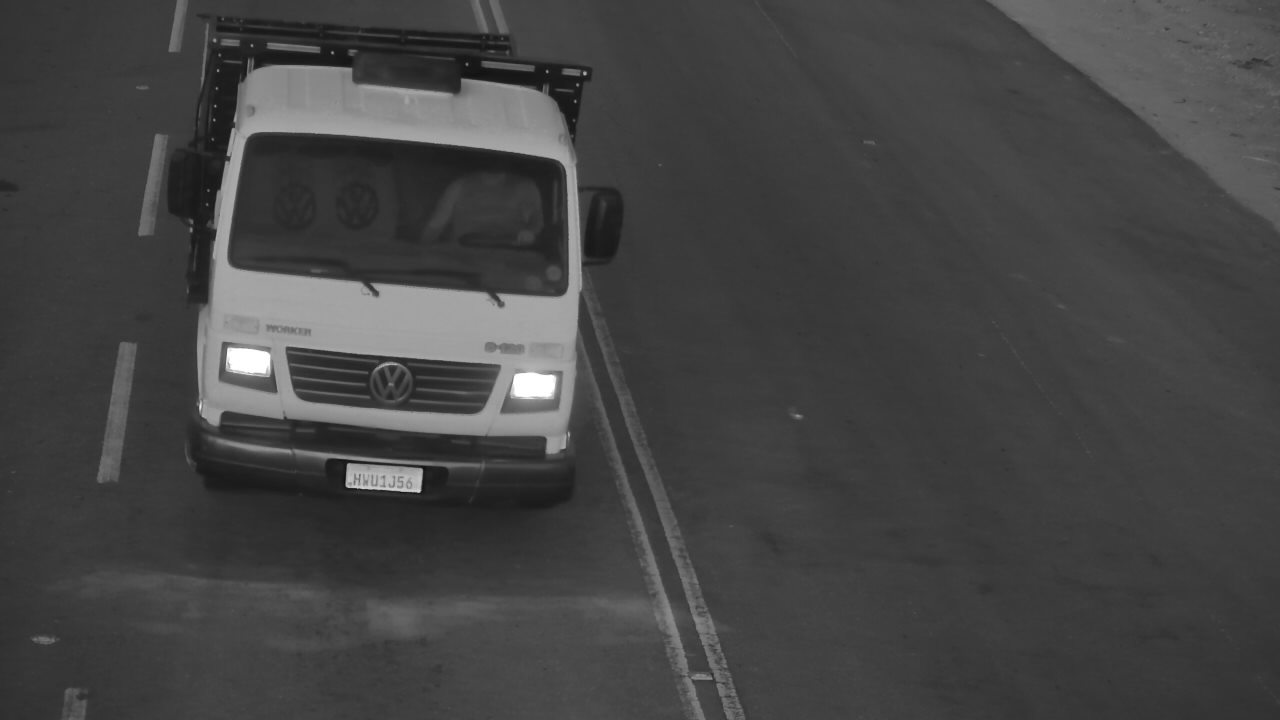

#### Aplicação de data augmentation



Após a remoção das imagens consideradas inadequadas para o treinamento, o conjunto de dados sofreu uma redução significativa, passando de mil para cerca de duzentas instâncias. Essa diminuição compromete a capacidade de generalização do modelo, uma vez que volumes reduzidos de dados tendem a limitar o aprendizado de padrões relevantes. Diante disso, optou-se pela aplicação de técnicas de superamostragem (*data augmentation*) sobre as imagens remanescentes, com o objetivo de ampliar artificialmente o conjunto de dados e mitigar os efeitos da escassez amostral. As transformações empregadas foram:

*   **Flip:** a imagem foi invertida horizontalmente;

*   **Brilho:** as configurações de brilho da imagem foram alteradas;

*   **Ruído:** foi adicionado um ruído suave nas imagens.

A aplicação dessas técnicas foi implementada de acordo com o código abaixo.

```python
imgs = os.listdir(path_selected) # Armazena as imagens a partir do caminho no Drive

augmentations = ["flip", "bright", "noise"]

for img_name in imgs:
    if img_name.startswith(tuple(a + "_" for a in augmentations)):
        continue # Ignora imagens que já são augmentations

    img_path = os.path.join(path_selected, img_name)
    img = cv2.imread(img_path)

    if img is None:
        print("Erro ao carregar:", img_name)
        continue

    name, ext = os.path.splitext(img_name)

    if "_" in name: # Padroniza o nome das imagens
        base, id_part = name.rsplit("_", 1)
    
    else:
        match = re.match(r"([a-zA-Z]+)(\d+)", name)

        if not match:
            print("Nome fora do padrão:", img_name)
            continue

        base = match.group(1)
        id_part = match.group(2)

    new_base_name = f"{base}_{id_part}"

    # Renomear se necessário
    new_original_name = f"{new_base_name}{ext}"
    new_original_path = os.path.join(path_selected, new_original_name)

    if img_name != new_original_name:
        os.rename(img_path, new_original_path)
        img_path = new_original_path

    img = cv2.imread(img_path)

    # Flip
    flip_name = f"flip_{new_base_name}{ext}"
    flip_path = os.path.join(path_selected, flip_name)

    if not os.path.exists(flip_path):
        flipped = cv2.flip(img, 1)
        cv2.imwrite(flip_path, flipped)

        print("Criado:", flip_name)

    # Brilho
    bright_name = f"bright_{new_base_name}{ext}"
    bright_path = os.path.join(path_selected, bright_name)

    if not os.path.exists(bright_path):
        bright = cv2.convertScaleAbs(img, alpha=1.0, beta=35)
        cv2.imwrite(bright_path, bright)

    # Ruído suave
    noise_name = f"noise_{new_base_name}{ext}"
    noise_path = os.path.join(path_selected, noise_name)

    if not os.path.exists(noise_path):
        noise = np.random.normal(0, 8, img.shape).astype(np.int16)
        noisy_img = img.astype(np.int16) + noise
        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

        cv2.imwrite(noise_path, noisy_img)
```

Com isso, foi possível aumentar a quantidade de instâncias adequadas para treinamento de cerca de duzentas imagens para 820.

### 2.2 Rotulação das imagens

Após o tratamento adequado das imagens, foi feita a rotulação manual de features relevantes para o treinamento. Para isso, foi usada a ferramenta `labelme`, que permite a definição de rótulos específicos e a criação de *bouding boxes* para delimitar a ocorrência desse rótulo. Neste primeiro momento, optou-se por utilizar o pneu, e não o eixo, como característica alvo, devido à maior facilidade de detecção por algoritmos de aprendizado de máquina. A rotulação de eixos, especialmente quando realizada manualmente, é mais suscetível a ambiguidades e erros, o que pode introduzir viés no modelo. A identificação dessa característica será feita posteriormente.

### 2.3 Treinamento com o YOLOv8

Após a organização das anotações, é possível treinar um modelo de detecção de objetos por meio de algoritmos de aprendizado de máquina. Neste trabalho, optou-se por usar o **YOLO** em sua arquitetura **v8**. O **YOLO** é um modelo de detecção em tempo real que realiza a identificação e a localização de objetos em uma única etapa, prevendo diretamente as *bounding boxes* e suas respectivas classes.

O desempenho do modelo YOLO também depende da organização adequada dos dados no projeto. Para isso, os arquivos foram estruturados em diretórios específicos, conforme a seguinte divisão:

```
data/                 # Dataset concentrado em um diretório
├── train/            # Conjunto de treinamento
│   ├── images/
│   └── labels/
├── val/              # Conjunto de validação
│   ├── images/
│   └── labels/
└── test/             # Conjunto de teste
    ├── images/
    └── labels/

custom_dataset.yaml   # Especificação das rotas para o algoritmo
```

O treinamento do modelo será feito com o conjunto de treinamento e o aprendizado será automaticamente verificado com o conjunto de validação. Após isso, é possível avaliar o desempenho do modelo criado com o conjunto de teste.

O treinamento completo pode ser visto nas células abaixo:

In [ ]:
%load_ext autoreload
%autoreload 2 # Serve para recarregar automaticamente os módulos editados

In [ ]:
# Define uma semente fixa para reprodutibilidade
RANDOM_SEED = 42

Para organizar os dados da forma supracitada, é necessário realizar uma divisão amostral.

In [ ]:
from utils import split_train_val

split_train_val(train_ratio = 0.7,          # Proporção de instâncias que ficarão no treinamento
                val_ratio   = 0.2,          # Proporção de instâncias que ficarão na validação
                test_ratio  = 0.1,          # Proporção de instâncias que ficarão no teste
                random_seed = RANDOM_SEED)  # Semente de aletoriedade definida para permitir reprodução

{'total': 820, 'train': 574, 'val': 164, 'test': 82}

Uma vez que se faz isso, é possível começar o treinamento de fato.

In [4]:
# Importação da bilbioteca que contém a classe YOLO
%pip install ultralytics 

  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------- ----- 1.0/1.2 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 7.7 MB/s  0:00:00
   ---------------------------------------- 0.0/824.0 kB ? eta -:--:--
   ---------------------------------------- 824.0/824.0 kB 37.5 MB/s  0:00:00
   ---------------------------------------- 0.0/47.0 MB ? eta -:--:--
   -------- ------------------------------- 10.0/47.0 MB 51.9 MB/s eta 0:00:01
   ---------------- ----------------------- 19.7/47.0 MB 49.7 MB/s eta 0:00:01
   ------------------------- -------------- 29.6/47.0 MB 49.5 MB/s eta 0:00:01
   --------------------------------- ------ 39.3/47.0 MB 49.0 MB/s eta 0:00:01
   ---------------------------------------  46.9/47.0 MB 49.0 MB/s eta 0:00:01
   -------------------------------------

ERROR: Could not install packages due to an OSError: [WinError 5] Acesso negado: 'c:\\Python312\\share'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from ultralytics import YOLO, settings

settings.update({'datasets_dir': '/home/aria-unimed/axle-detection-herick/'})

model = YOLO('yolov8n') # Inicia com a arquitetura padrão, por ora

ModuleNotFoundError: No module named 'ultralytics'

Em breve, alterar arquitetura para buscar ajustar ao problema específico, e não usar a arquitetura genérica.

In [ ]:
# Treinamento do algoritmo
model.train(data = 'custom_dataset.yaml',
            epochs = 30,
            patience = 5,       # Número de épocas sem melhoria para parar o treinamento
            batch = -1,         # Usar o batch size padrão, que é o melhor para a arquitetura escolhida
            imgsz = 640,        # Tamanho da imagem de entrada
            workers = 8,        # Número de threads utilizadas
            pretrained = True,  # Usar pesos pré-treinados para acelerar o treinamento
            resume = False,     # Não retomar de um treinamento anterior
            box = 7.5,          # Peso para a perda de caixa delimitadora
            cls = 0.5,          # Peso para a perda de classificação
            dfl = 1.5,          # Peso para a perda de distribuição de distância
            val = True,         # Realizar validação durante o treinamento para monitorar o desempenho do modelo
            seed = RANDOM_SEED) # Semente para reprodutibilidade

### 2.4 Teste do modelo

Após o treinamento do modelo e a validação automática, é possível confirmar seu desempenho por meio de identificações feitas de forma inédita no conjunto de teste.

In [ ]:
# Carrega o melhor modelo treinado
model = YOLO("runs/detect/train4/weights/best.pt")

# Roda avaliação no conjunto de teste
metrics = model.val(data="custom_dataset.yaml", split="test")

### 3.0 Avaliação do modelo

### 4.0 Uso prático